# Exploratory Analysis

## Importing packages and libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates

## Loading data

In [2]:
df = pd.read_csv("./data/unemployment.csv")

## Peaking at the data

As we can note from looking at the top observation the data that the data is note ordered by ascending dates.

In [3]:
df.head()

,date,unemployment_rate
0,2026-05-01,3.0
1,2026-04-01,3.1
2,2026-03-01,3.2
3,2026-02-01,3.4
4,2026-01-01,3.3


This is easily fixed.

In [4]:
df.sort_values(by = "date", inplace=True)

It is also noted that none of the columns contains missing 

In [5]:
df.isna().sum()

date                 0
unemployment_rate    0
dtype: int64

The dates are converted to the native python datetime format.

In [6]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

## Plotting the data

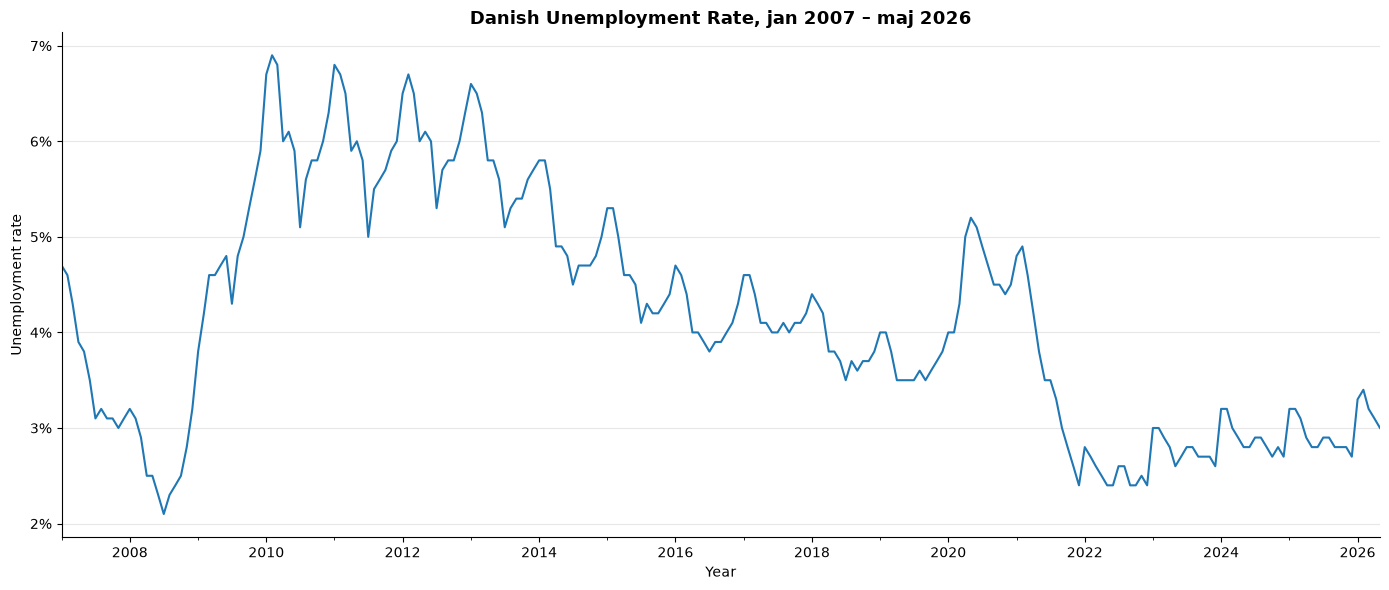

In [7]:
fig, ax = plt.subplots(figsize = (14, 6))

x = df["date"]
y = df["unemployment_rate"]
min_x = min(x)
max_x = max(x)

ax.plot(x, y, color = "#1f77b4", linewidth = 1.5)
ax.set_title(f"Danish Unemployment Rate, {min_x:%b %Y} \u2013 {max_x:%b %Y}", fontsize = 13, weight = "bold")
ax.set_xlabel("Year")
ax.set_ylabel("Unemployment rate")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))

ax.set_xlim(min_x, max_x)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

ax.grid(True, which = "major", axis = "y", alpha = 0.3)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()


Inspecting the plot shows there is alot of clear seasonality.